# A tour of the geepers analysis modules

This notebook demonstrates the GNSS velocity-analysis toolbox that ships with
[geepers](https://github.com/isce-framework/geepers):

1. **MIDAS** — robust velocities (Blewitt et al., 2016)
2. **`geepers.trend`** — velocities with *realistic* uncertainties under power-law + white noise (Bos et al., 2013)
3. **`geepers.variability`** — temporal and spatial station-stability metrics
4. **`geepers.gps_imaging`** — robust weighted-median interpolation (Hammond et al., 2016)
5. **`geepers.collocation`** — least-squares collocation with covariance propagation

Everything below runs on synthetic data in a couple of minutes — no downloads needed.
The last section shows the same tools on real UNR data (needs network).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110

## 1. Synthetic GNSS time series

We build a daily series with a known trend, an annual cycle, a step, white noise,
and power-law (flicker) noise — the realistic mix that makes GNSS velocity
uncertainties hard.

/u/aurora-r0/govorcin/miniconda/miniforge/envs/geepers-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


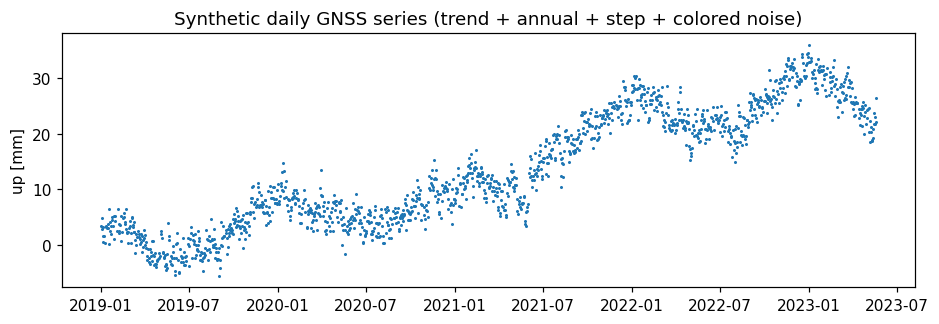

In [2]:
from geepers.trend import _fractional_diff_coeffs

n = 1600  # ~4.4 years, keeps the MLE fast in this demo
dates = pd.date_range("2019-01-01", periods=n, freq="D")
t_yr = np.arange(n) / 365.25

TRUTH = {"velocity": 5.0, "annual": 3.0, "step": 8.0, "sigma_white": 1.0, "sigma_pl": 1.5, "kappa": -1.0}

psi = _fractional_diff_coeffs(-TRUTH["kappa"] / 2, n)
flicker = np.convolve(rng.normal(0, TRUTH["sigma_pl"], n), psi)[:n]

y = (
    TRUTH["velocity"] * t_yr
    + TRUTH["annual"] * np.cos(2 * np.pi * t_yr)
    + TRUTH["step"] * (dates >= "2021-06-01")
    + rng.normal(0, TRUTH["sigma_white"], n)
    + flicker
)
# knock out 10% of days to simulate gaps
keep = rng.random(n) > 0.10
dates_obs, y_obs = dates[keep], y[keep]

plt.figure(figsize=(10, 3))
plt.plot(dates_obs, y_obs, ".", ms=2)
plt.ylabel("up [mm]")
plt.title("Synthetic daily GNSS series (trend + annual + step + colored noise)")
plt.show()

## 2. MIDAS: robust velocity

MIDAS forms one-year data pairs, so seasonal signals cancel; the median of the
pair velocities shrugs off outliers. Known steps are passed so no pair spans them.

In [3]:
from geepers.midas import midas

t_years_obs = (dates_obs - dates_obs[0]).total_seconds().to_numpy() / 86400 / 365.25
step_years = np.array([(pd.Timestamp("2021-06-01") - dates_obs[0]).days / 365.25])

m = midas(t_years_obs, y_obs, step_years)
print(f"MIDAS velocity: {m.velocity:.2f} ± {m.velocity_uncertainty:.2f} mm/yr  (truth {TRUTH['velocity']})")

MIDAS velocity: 4.54 ± 0.64 mm/yr  (truth 5.0)


## 3. Trend with noise modeling: honest uncertainties

`estimate_trend` fits trend + annual + semi-annual + the step *jointly* with a
power-law + white noise model by restricted maximum likelihood. Compare the
uncertainty with a white-noise-only (OLS-equivalent) fit — colored noise typically
inflates GNSS velocity sigmas by 5–10×.

This is the slowest cell (~1–2 minutes): the likelihood needs a Cholesky
factorization of the full covariance at every optimizer step.

In [4]:
from geepers.trend import estimate_trend

res_wn = estimate_trend(dates_obs, y_obs, step_dates=["2021-06-01"], noise_model="WN")
res_pl = estimate_trend(dates_obs, y_obs, step_dates=["2021-06-01"], noise_model="PLWN")

print(f"truth    : v = {TRUTH['velocity']:.2f} mm/yr, kappa = {TRUTH['kappa']}")
print(f"WN  (OLS): v = {res_wn.velocity:.2f} ± {res_wn.velocity_uncertainty:.2f} mm/yr")
print(f"PL+WN    : v = {res_pl.velocity:.2f} ± {res_pl.velocity_uncertainty:.2f} mm/yr, "
      f"kappa = {res_pl.kappa:.2f}, step = {res_pl.parameters['step_0'][0]:.1f} mm")
print(f"uncertainty ratio PLWN/WN: {res_pl.velocity_uncertainty / res_wn.velocity_uncertainty:.1f}x")

truth    : v = 5.00 mm/yr, kappa = -1.0
WN  (OLS): v = 4.33 ± 0.10 mm/yr
PL+WN    : v = 4.71 ± 0.51 mm/yr, kappa = -0.85, step = 7.6 mm
uncertainty ratio PLWN/WN: 5.1x


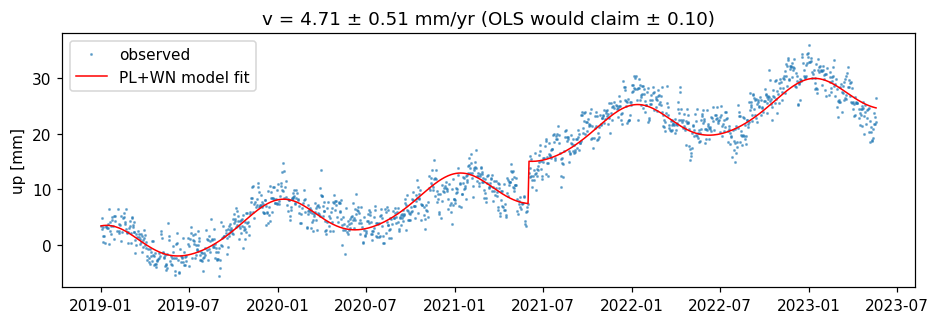

In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dates_obs, y_obs, ".", ms=2, alpha=0.5, label="observed")
ax.plot(dates_obs, res_pl.model, "r-", lw=1, label="PL+WN model fit")
ax.set_ylabel("up [mm]")
ax.legend()
ax.set_title(
    f"v = {res_pl.velocity:.2f} ± {res_pl.velocity_uncertainty:.2f} mm/yr "
    f"(OLS would claim ± {res_wn.velocity_uncertainty:.2f})"
)
plt.show()

## 4. Temporal velocity variability

How much does the velocity depend on *when* you measure it? Sliding-window MIDAS
velocities of every length from 3 years up, reduced to one number per component:
`sqrt(median((v_window − v_full)²))`.

temporal variability [mm/yr]: {'east': 1.92, 'north': 1.92, 'up': 1.92}


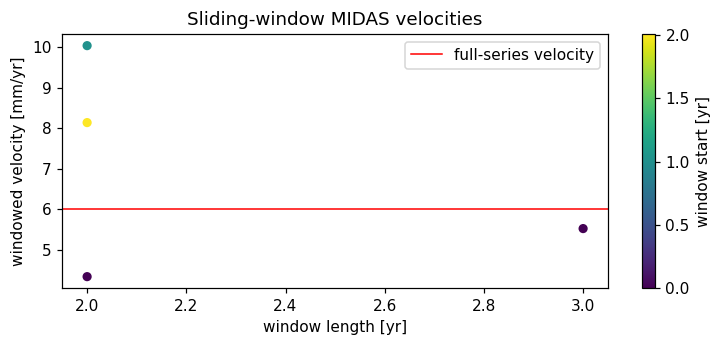

In [6]:
from geepers.variability import temporal_velocity_variability

enu = np.c_[y_obs, y_obs, y_obs]  # reuse the same series for the demo
tv = temporal_velocity_variability(dates_obs, enu, min_window_years=2.0)
print("temporal variability [mm/yr]:", {k: round(v, 2) for k, v in tv.variability.items()})

w = tv.window_velocities
plt.figure(figsize=(8, 3))
sc = plt.scatter(w["length_years"], w["up"], c=w["start"], cmap="viridis", s=25)
plt.axhline(tv.full_velocity["up"], color="r", lw=1, label="full-series velocity")
plt.colorbar(sc, label="window start [yr]")
plt.xlabel("window length [yr]"); plt.ylabel("windowed velocity [mm/yr]")
plt.legend(); plt.title("Sliding-window MIDAS velocities")
plt.show()

## 5. A synthetic velocity *field*: spatial metrics + robust interpolation

Now a network of 150 stations sampling a smooth vertical-velocity field with a
sharp uplift boundary — plus one gross outlier station.

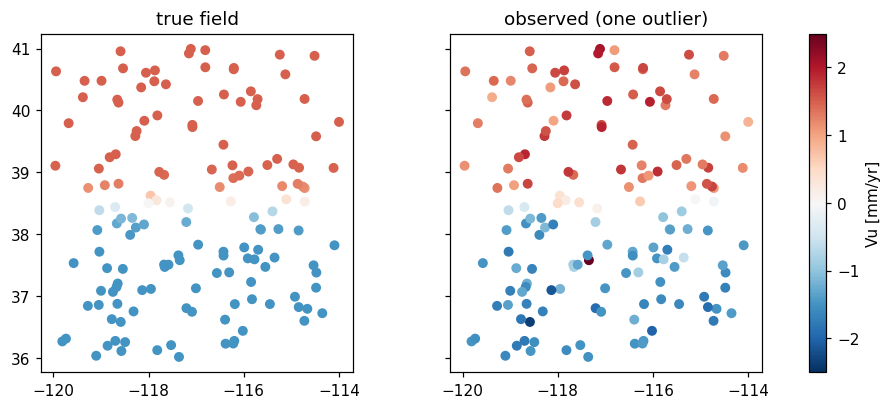

In [7]:
n_sta = 150
lon = rng.uniform(-120, -114, n_sta)
lat = rng.uniform(36, 41, n_sta)
sv = np.full(n_sta, 0.4)

v_field = 1.5 * np.tanh((lat - 38.5) * 4)  # sharp east-west boundary at 38.5N
v_up = v_field + rng.normal(0, 0.3, n_sta)
v_up[17] += 25.0  # a bad station

def field_plot(ax, c, title, vmin=-2.5, vmax=2.5):
    s = ax.scatter(lon, lat, c=c, cmap="RdBu_r", vmin=vmin, vmax=vmax, s=30)
    ax.set_title(title); ax.set_aspect(1.3)
    return s

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
field_plot(ax[0], v_field, "true field")
s = field_plot(ax[1], v_up, "observed (one outlier)")
fig.colorbar(s, ax=ax, label="Vu [mm/yr]")
plt.show()

In [8]:
from geepers.variability import spatial_variability

svar = spatial_variability(lon, lat, v_up)
print("station 17 neighbor-RMS:", svar['rms'][17].round(1), "mm/yr  <- flags the outlier")
print("median neighbor-RMS    :", svar['rms'].median().round(2), "mm/yr")

station 17 neighbor-RMS: 25.3 mm/yr  <- flags the outlier
median neighbor-RMS    : 0.41 mm/yr


### GPS Imaging: SSF + median spatial filter

`make_ssf` measures how coherence decays with distance; `median_spatial_filter`
replaces each station by the SSF-weighted median of its Delaunay neighborhood —
the outlier disappears while the sharp boundary survives (no smoothing).
`msf_interpolate` evaluates the same estimator anywhere.

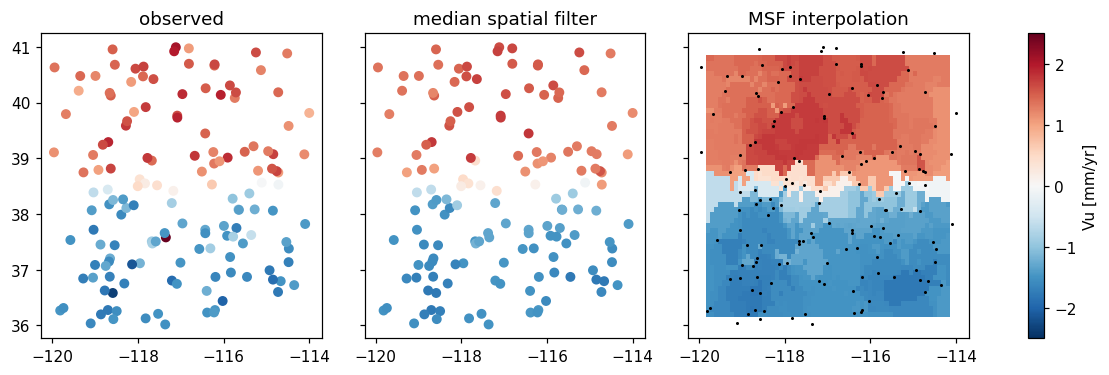

In [9]:
from geepers.gps_imaging import make_ssf, median_spatial_filter, msf_interpolate

ssf = make_ssf(lon, lat, v_up, sv, max_difference=10)
v_msf = median_spatial_filter(lon, lat, v_up, sv, ssf)

# interpolate onto a regular grid
gx, gy = np.meshgrid(np.linspace(-119.8, -114.2, 60), np.linspace(36.2, 40.8, 50))
grid = msf_interpolate(lon, lat, v_up, sv, gx.ravel(), gy.ravel(), ssf)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
plt.subplots_adjust(wspace=0.05)
field_plot(ax[0], v_up, "observed")
field_plot(ax[1], v_msf, "median spatial filter")
im = ax[2].pcolormesh(gx, gy, grid["value"].to_numpy().reshape(gx.shape),
                      cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax[2].plot(lon, lat, "k.", ms=2); ax[2].set_title("MSF interpolation"); ax[2].set_aspect(1.3)
fig.colorbar(im, ax=ax, label="Vu [mm/yr]")
plt.show()

### Least-squares collocation

The geostatistical alternative: fit an empirical covariance model, then predict
signal *and uncertainty* everywhere. Smoother than GPS Imaging, with rigorous
error propagation — but not outlier-robust, so feed it the filtered field.

fitted covariance: C0 = 1.86  d0 = 118.0 km


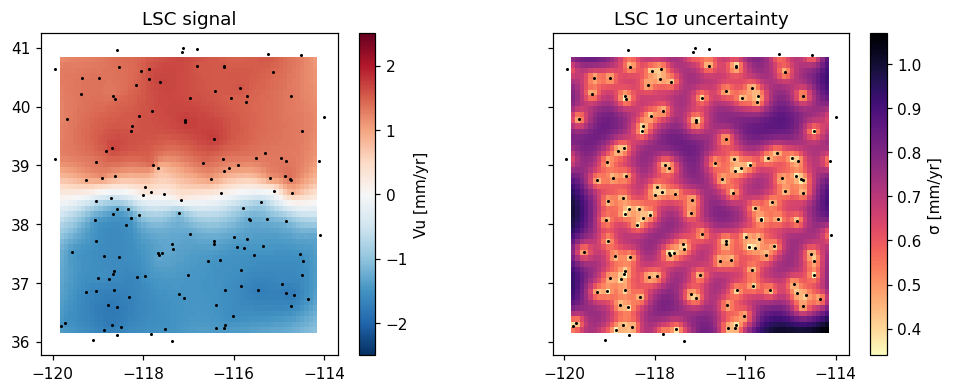

In [10]:
from geepers.collocation import (
    collocate,
    empirical_covariance,
    noise_covariance,
    predict,
    signal_covariance,
)

emp = empirical_covariance(lon, lat, v_msf, v_msf, sv, sv, bin_spacing_km=30)
print("fitted covariance: C0 =", emp.parameters[0].round(2), " d0 =", emp.parameters[1].round(0), "km")

Css = signal_covariance(lon, lat, lon, lat, emp.parameters, components=("up",))
Cnn = noise_covariance(sv)
at_sta, Czz_inv = collocate(v_msf, Css, Cnn)

Cps = signal_covariance(lon, lat, gx.ravel(), gy.ravel(), emp.parameters, components=("up",))
Cpp = signal_covariance(gx.ravel(), gy.ravel(), gx.ravel(), gy.ravel(), emp.parameters, components=("up",))
at_grid = predict(v_msf, Cps, Cpp, Czz_inv)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
im0 = ax[0].pcolormesh(gx, gy, at_grid.signal[:, 0].reshape(gx.shape), cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax[0].plot(lon, lat, "k.", ms=2); ax[0].set_title("LSC signal"); ax[0].set_aspect(1.3)
fig.colorbar(im0, ax=ax[0], label="Vu [mm/yr]")
im1 = ax[1].pcolormesh(gx, gy, at_grid.signal_sigma[:, 0].reshape(gx.shape), cmap="magma_r")
ax[1].plot(lon, lat, "k.", ms=2); ax[1].set_title("LSC 1σ uncertainty"); ax[1].set_aspect(1.3)
fig.colorbar(im1, ax=ax[1], label="σ [mm/yr]")
plt.show()

Note how the uncertainty map lights up away from stations — that spatial
error propagation is what collocation buys you over GPS Imaging, which in turn
is the tool of choice when the data contain outliers or sharp boundaries.

## 6. Interpolating across a plate boundary

A covariance model only knows *distance*, so stations on opposite sides of a
plate boundary contaminate each other and the velocity discontinuity gets
smeared. `separate_plates` pushes each plate's points apart in a working
coordinate space (≥1500 km), making cross-plate covariance effectively zero —
interpolate there, then attach results back to the true coordinates.

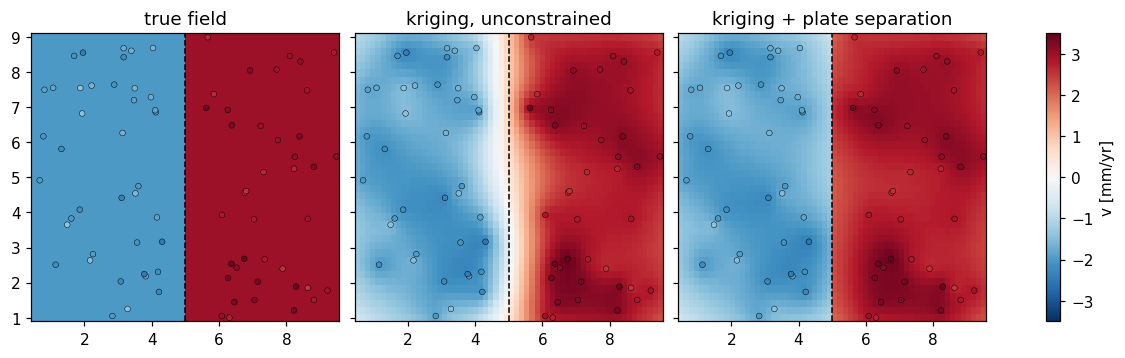

unconstrained: step across boundary = 1.87 mm/yr (truth 5.0)
constrained  : step across boundary = 4.03 mm/yr (truth 5.0)


In [11]:
import geopandas as gpd
from shapely.geometry import box as sbox

from geepers.collocation import ordinary_kriging, separate_plates

# Two plates meeting at lon = 5°, with a 5 mm/yr velocity step
plates = gpd.GeoDataFrame({"code": ["A", "B"]},
                          geometry=[sbox(0, 0, 5, 10), sbox(5, 0, 10, 10)],
                          crs="EPSG:4326")
n_p = 80
plon = np.r_[rng.uniform(0.5, 4.5, n_p // 2), rng.uniform(5.5, 9.5, n_p // 2)]
plat = rng.uniform(1, 9, n_p)
pv = np.where(plon < 5, -2.0, 3.0) + rng.normal(0, 0.3, n_p)
psv = np.full(n_p, 0.3)
pgx, pgy = np.meshgrid(np.linspace(0.5, 9.5, 60), np.linspace(1, 9, 40))

# Separate stations AND grid nodes together (consistent working coords)
all_lon = np.r_[plon, pgx.ravel()]
all_lat = np.r_[plat, pgy.ravel()]
lon_m, lat_m, plate_idx = separate_plates(all_lon, all_lat, plates,
                                          min_separation_km=1500)

params = np.array([1.0, 200.0])
unconstrained = ordinary_kriging(plon, plat, pv, psv,
                                 pgx.ravel(), pgy.ravel(), params)
constrained = ordinary_kriging(lon_m[:n_p], lat_m[:n_p], pv, psv,
                               lon_m[n_p:], lat_m[n_p:], params)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
plt.subplots_adjust(wspace=0.05)
for a, fld, title in [
    (ax[0], np.where(pgx < 5, -2.0, 3.0), "true field"),
    (ax[1], unconstrained.signal.reshape(pgx.shape), "kriging, unconstrained"),
    (ax[2], constrained.signal.reshape(pgx.shape), "kriging + plate separation"),
]:
    im = a.pcolormesh(pgx, pgy, np.asarray(fld, float), cmap="RdBu_r", vmin=-3.5, vmax=3.5)
    a.scatter(plon, plat, c=pv, cmap="RdBu_r", vmin=-3.5, vmax=3.5,
              s=14, edgecolors="k", linewidths=0.3)
    a.axvline(5, color="k", ls="--", lw=1)
    a.set_title(title)
fig.colorbar(im, ax=ax, label="v [mm/yr]")
plt.show()

# quantify the boundary step recovered just left/right of lon = 5
li, ri = np.argmin(np.abs(pgx[0] - 4.6)), np.argmin(np.abs(pgx[0] - 5.4))
for name, f in [("unconstrained", unconstrained), ("constrained  ", constrained)]:
    v2 = f.signal.reshape(pgx.shape)
    print(f"{name}: step across boundary = {v2[:, ri].mean() - v2[:, li].mean():.2f} mm/yr (truth 5.0)")

The same moved coordinates work for `interpolate_velocities` and
`gps_imaging.msf_interpolate`. For horizontal fields, remove each plate's
rigid rotation (Euler pole) before interpolating and restore it after —
vertical velocities need no such correction.

## 7. Real data (optional — needs network)

The same tools plug directly into the geepers data sources. Uncomment to run:

In [12]:
# from geepers.gps_sources import UnrSource
#
# src = UnrSource()
# df = src.timeseries("P123", start_date="2015-01-01")
# steps = src.steps(station_ids=["P123"])
#
# res = estimate_trend(
#     df["date"], df["up"] * 1000,  # meters -> mm
#     step_dates=steps["date"].tolist(),
# )
# print(f"P123 up: {res.velocity:.2f} ± {res.velocity_uncertainty:.2f} mm/yr, kappa={res.kappa:.2f}")